In [26]:
# ================================
# 1. Import Required Libraries
# ================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense,Conv2D
import matplotlib.pyplot as plt

In [27]:
# 2. Load MNIST Dataset
# ================================
# MNIST contains 60,000 training images and 10,000 test images
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [28]:
# ================================
# 3. Data Preprocessing
# ================================

# Normalize pixel values (0–255 → 0–1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [29]:
# Reshape data to add channel dimension (28,28 → 28,28,1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [30]:
x_train.reshape
x_test.reshape

<function ndarray.reshape>

In [ ]:
# ================================
# 4. Build CNN Model
# ================================
model = keras.Sequential([

    # First Convolution Layer
    layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Layer
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Flatten Layer
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),

    # Output Layer (10 classes: digits 0–9)
    layers.Dense(10, activation='softmax')
])

c:\Users\KIRAN GHANTASALA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
# ================================
# 5. Compile Model
# ================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
# ================================
# 6. Train Model (Training Happens First)
# ================================
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9483 - loss: 0.1729 - val_accuracy: 0.9853 - val_loss: 0.0575
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9846 - loss: 0.0501 - val_accuracy: 0.9890 - val_loss: 0.0418
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9888 - loss: 0.0356 - val_accuracy: 0.9897 - val_loss: 0.0384
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9915 - loss: 0.0251 - val_accuracy: 0.9897 - val_loss: 0.0350
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9938 - loss: 0.0193 - val_accuracy: 0.9900 - val_loss: 0.0360


In [34]:
# ================================
# 7. Test Model (Testing Happens After Training)
# ================================
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9905 - loss: 0.0298
Test Loss: 0.02979193441569805
Test Accuracy: 0.9904999732971191


In [35]:
# ================================
# 8. Make Predictions
# ================================
predictions = model.predict(x_test)

# Show first prediction
print("Predicted Digit:", predictions[0].argmax())
print("Actual Digit:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Predicted Digit: 7
Actual Digit: 7


In [36]:
sample_index = 2
img = x_test[sample_index]
true_label=y_test[sample_index]

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

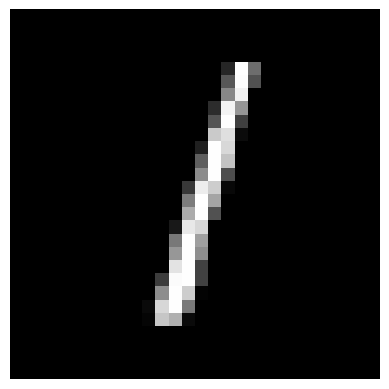

In [37]:
plt.imshow(img.reshape(28,28),cmap='gray')
plt.axis('off')

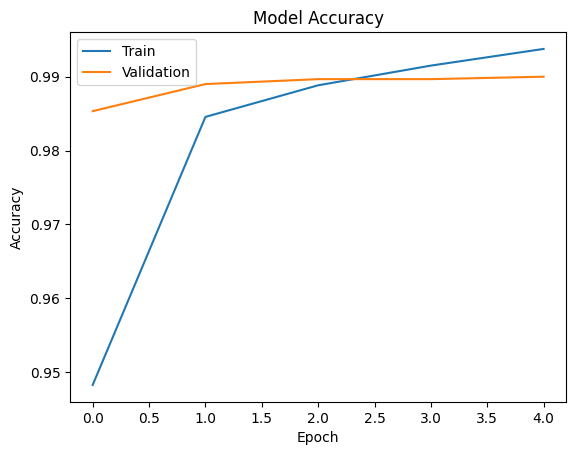

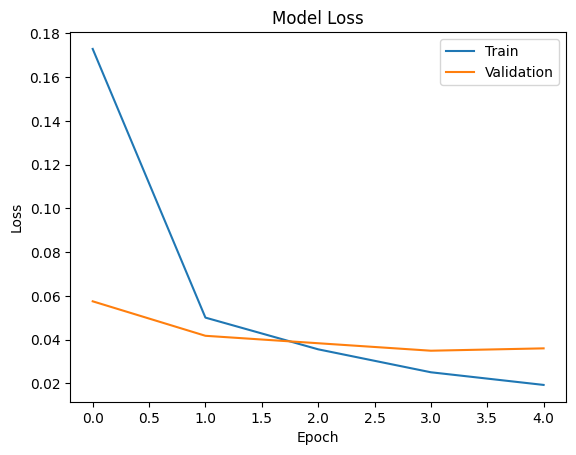

In [38]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Plot Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


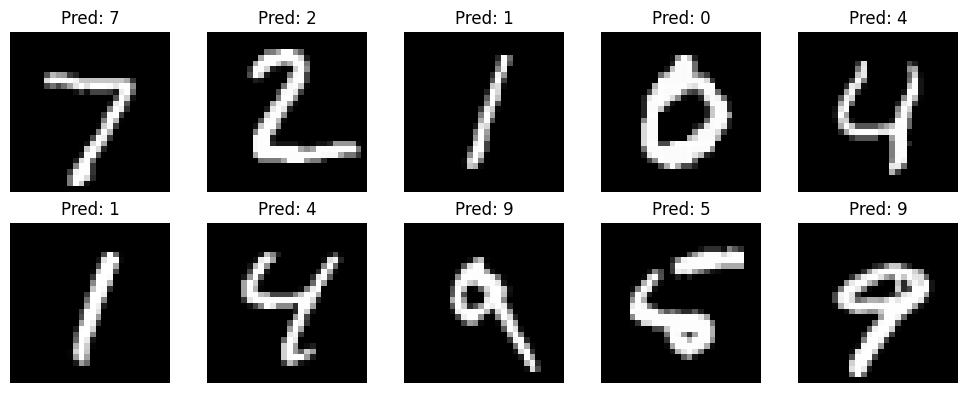

In [39]:
import numpy as np

# Predict on test data
predictions = model.predict(x_test)

# Show first 10 test images with predictions
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {np.argmax(predictions[i])}")
    plt.axis('off')

plt.tight_layout()
plt.show()


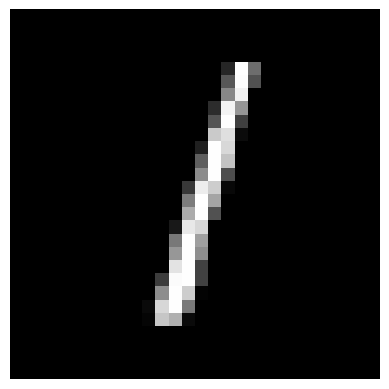

In [40]:
plt.imshow(x_test[2].reshape(28,28), cmap='gray')
plt.axis('off')
plt.show()

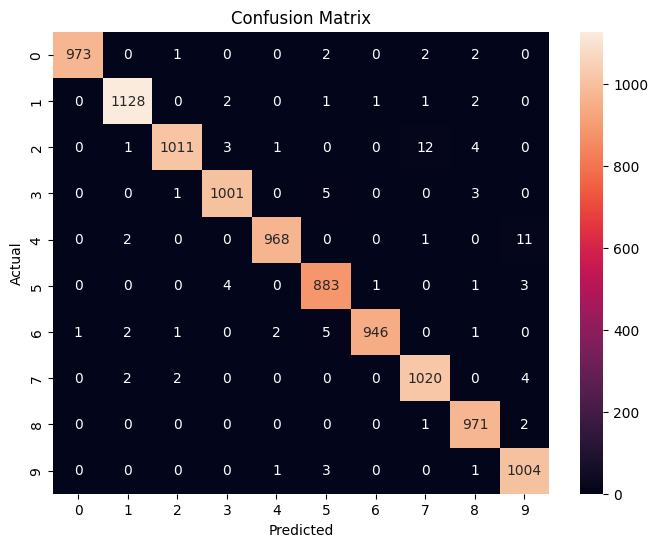

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predicted labels
y_pred = np.argmax(predictions, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
